In [1]:
# Re-run with safer anomaly injection indices (using positions within bounds).
from pathlib import Path
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import RobustScaler
import joblib
import random
import os


In [3]:
df = pd.read_csv('/content/IoT_Tank_Sensor_Data_21days.csv')
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
base = df.copy().set_index('Timestamp')
cols = ['Liquid_Level(L)','Flow_Rate(L/min)','Pressure(bar)','Temperature(C)','Motor_Current(A)','Vibration(mm/s)']

In [4]:
df.head()

,Timestamp,Liquid_Level(L),Flow_Rate(L/min),Pressure(bar),Temperature(C),Motor_Current(A),Vibration(mm/s),Anomaly_Type
0,2025-07-25 00:00:00,7509.9,13.87,2.85,25.3,3.09,0.82,Normal
1,2025-07-25 01:00:00,7497.2,13.96,2.77,24.9,3.00,1.10,Normal
2,2025-07-25 02:00:00,7513.0,13.90,2.87,25.5,3.13,0.84,Normal
3,2025-07-25 03:00:00,7530.5,13.77,2.81,25.5,3.04,0.77,Normal
4,2025-07-25 04:00:00,7495.3,14.22,2.90,26.0,3.10,0.89,Normal


In [5]:
def synthesize_series(base_df, days=30, seed=42):
    rng = np.random.RandomState(seed)
    rows = []
    start = pd.Timestamp('2025-07-25 00:00')
    for day in range(days):
        for t, row in base_df.iterrows():
            ts = start + pd.Timedelta(days=day) + pd.Timedelta(hours=t.hour)
            vals = row[cols].values.astype(float)
            noise = rng.normal(scale=[5,0.3,0.05,0.2,0.05,0.05])
            vals = vals + noise * (1 + 0.1*rng.randn())
            rows.append([ts] + vals.tolist() + ['Normal'])
    big = pd.DataFrame(rows, columns=['Timestamp']+cols+['Anomaly_Type']).set_index('Timestamp')
    return big

big = synthesize_series(base, days=30, seed=0)
big.index = pd.DatetimeIndex(big.index)
big = big.sort_index()


In [6]:
def inject_leak(df, idx_pos, duration_hours=12, rate= -5.0):
    df = df.copy()
    n = len(df)
    start_pos = idx_pos % n
    for i in range(duration_hours):
        pos = start_pos + i
        if pos < n:
            df.iloc[pos, df.columns.get_loc('Liquid_Level(L)')] += rate * (i+1)/duration_hours
            df.iloc[pos, df.columns.get_loc('Anomaly_Type')] = 'Leak'
    return df

def inject_blockage(df, idx_pos, duration_hours=6, drop= -8.0):
    df = df.copy()
    n = len(df)
    start_pos = idx_pos % n
    for i in range(duration_hours):
        pos = start_pos + i
        if pos < n:
            df.iloc[pos, df.columns.get_loc('Flow_Rate(L/min)')] += drop
            df.iloc[pos, df.columns.get_loc('Anomaly_Type')] = 'Blockage'
    return df

def inject_spike_sensor(df, idx_pos):
    df = df.copy()
    n = len(df)
    pos = idx_pos % n
    df.iloc[pos, df.columns.get_loc('Vibration(mm/s)')] += 5.0
    df.iloc[pos, df.columns.get_loc('Anomaly_Type')] = 'Spike'
    return df


In [7]:
# choose positions safely
n = len(big)
big = inject_leak(big, idx_pos=n//4, duration_hours=18, rate=-10.0)
big = inject_blockage(big, idx_pos=n//2, duration_hours=8, drop=-6.0)
big = inject_spike_sensor(big, idx_pos=3*n//4)

data_full = big.copy()


In [8]:
# Preprocess, features, scaling
df_feat = data_full.copy()
df_feat['hour'] = df_feat.index.hour
df_feat['hour_sin'] = np.sin(2*np.pi*df_feat['hour']/24.0)
df_feat['hour_cos'] = np.cos(2*np.pi*df_feat['hour']/24.0)
feature_cols = cols + ['hour_sin','hour_cos']

scaler = RobustScaler()
scaled = scaler.fit_transform(df_feat[feature_cols])
scaled_df = pd.DataFrame(scaled, index=df_feat.index, columns=feature_cols)
scaled_df['Anomaly_Type'] = df_feat['Anomaly_Type']


In [9]:
os.makedirs('/mnt/data/artifacts', exist_ok=True)
joblib.dump(scaler, '/mnt/data/artifacts/robust_scaler.pkl')


['/mnt/data/artifacts/robust_scaler.pkl']

In [10]:
seq_len = 24  # past 24 hours
pred_horizon = 1
X = []
Y = []
labels = []
for i in range(len(scaled_df)-seq_len-pred_horizon+1):
    x = scaled_df.iloc[i:i+seq_len][feature_cols].values.astype(np.float32)
    y = scaled_df.iloc[i+seq_len:i+seq_len+pred_horizon][cols].values.astype(np.float32)
    label = scaled_df.iloc[i+seq_len]['Anomaly_Type']
    X.append(x)
    Y.append(y.squeeze())
    labels.append(label)
X = np.stack(X)
Y = np.stack(Y)
labels = np.array(labels)


In [11]:
train_size = int(0.8 * len(X))
X_train, X_val = X[:train_size], X[train_size:]
Y_train, Y_val = Y[:train_size], Y[train_size:]
labels_train, labels_val = labels[:train_size], labels[train_size:]


In [12]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [13]:
class SimpleTimeSeriesTransformer(nn.Module):
    def __init__(self, n_inputs, d_model=64, nhead=4, num_layers=2, dim_feedforward=128, dropout=0.1, out_dim=None):
        super().__init__()
        self.input_proj = nn.Linear(n_inputs, d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward, dropout=dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.out = nn.Linear(d_model, out_dim if out_dim is not None else n_inputs)
    def forward(self, x):
        h = self.input_proj(x)
        h = self.transformer(h)
        h = h.transpose(1,2)
        h = self.pool(h).squeeze(-1)
        out = self.out(h)
        return out


In [14]:
n_features = len(feature_cols)
model = SimpleTimeSeriesTransformer(n_inputs=n_features, d_model=64, nhead=4, num_layers=2, dim_feedforward=128, out_dim=len(cols)).to(device)


In [15]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, Y):
        self.X = X
        self.Y = Y
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return torch.tensor(self.X[idx]), torch.tensor(self.Y[idx])

train_ds = TimeSeriesDataset(X_train, Y_train)
val_ds = TimeSeriesDataset(X_val, Y_val)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()


In [16]:
epochs = 8
for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * xb.size(0)
    train_loss /= len(train_loader.dataset)
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            pred = model(xb)
            loss = criterion(pred, yb)
            val_loss += loss.item() * xb.size(0)
    val_loss /= len(val_loader.dataset)
    print(f"Epoch {epoch+1}/{epochs} — train_loss={train_loss:.6f}, val_loss={val_loss:.6f}")

torch.save(model.state_dict(), '/mnt/data/artifacts/transformer_forecast.pth')


Epoch 1/8 — train_loss=0.590153, val_loss=0.565327
Epoch 2/8 — train_loss=0.582508, val_loss=0.553688
Epoch 3/8 — train_loss=0.580400, val_loss=0.551906
Epoch 4/8 — train_loss=0.577180, val_loss=0.550072
Epoch 5/8 — train_loss=0.575696, val_loss=0.548131
Epoch 6/8 — train_loss=0.572696, val_loss=0.546999
Epoch 7/8 — train_loss=0.571445, val_loss=0.550362
Epoch 8/8 — train_loss=0.568370, val_loss=0.548782


In [17]:
# residual-based scores
model.eval()
all_preds = []
with torch.no_grad():
    for i in range(len(X)):
        xb = torch.tensor(X[i:i+1]).to(device)
        pred = model(xb).cpu().numpy().squeeze()
        all_preds.append(pred)
all_preds = np.stack(all_preds)
true_vals = Y

residuals = np.linalg.norm(all_preds - true_vals, axis=1)
med = np.median(residuals)
iqr = np.subtract(*np.percentile(residuals, [75,25]))
anomaly_score = (residuals - med) / (iqr + 1e-9)
anomaly_score = 1 / (1 + np.exp(-anomaly_score))

pred_timestamps = scaled_df.index[seq_len:seq_len+len(anomaly_score)]
score_series = pd.Series(anomaly_score, index=pred_timestamps)
label_series = pd.Series(labels, index=pred_timestamps)

baseline_alarm = (score_series > 0.8).astype(int)
baseline_alarm = baseline_alarm.rolling(window=2, min_periods=1).sum() >= 2
baseline_alarm = baseline_alarm.astype(int)

eval_df = pd.DataFrame({
    'score': score_series,
    'label': label_series,
    'baseline_alarm': baseline_alarm
})
eval_df['is_anomaly'] = eval_df['label'] != 'Normal'


In [18]:
tp = ((eval_df['baseline_alarm']==1) & (eval_df['is_anomaly'])).sum()
fp = ((eval_df['baseline_alarm']==1) & (~eval_df['is_anomaly'])).sum()
fn = ((eval_df['baseline_alarm']==0) & (eval_df['is_anomaly'])).sum()
precision = tp / (tp+fp) if (tp+fp)>0 else 0.0
recall = tp / (tp+fn) if (tp+fn)>0 else 0.0
f1 = 2*precision*recall/(precision+recall) if (precision+recall)>0 else 0.0
print(f"Baseline rule — TP={tp}, FP={fp}, FN={fn}, Precision={precision:.3f}, Recall={recall:.3f}, F1={f1:.3f}")


Baseline rule — TP=8, FP=28, FN=19, Precision=0.222, Recall=0.296, F1=0.254


In [19]:
class AlarmEnv:
    def __init__(self, scores, labels, window=6):
        self.scores = np.array(scores)
        self.labels = np.array(labels)
        self.n = len(scores)
        self.window = window
        self.reset()
    def reset(self):
        self.t = 0
        self.done = False
        self.state = np.zeros(self.window, dtype=np.float32)
        return self.state.copy()
    def step(self, action):
        reward = 0.0
        info = {}
        if self.t >= self.n:
            self.done = True
            return self.state.copy(), 0.0, True, info
        true_label = self.labels[self.t]
        score = self.scores[self.t]
        if action == 1:
            if true_label:
                reward += 5.0
            else:
                reward -= 2.0
        elif action == 0:
            if true_label:
                reward -= 3.0
            else:
                reward += 0.1
        elif action == 2:
            reward += 0.0
        self.state = np.roll(self.state, -1)
        self.state[-1] = score
        self.t += 1
        if self.t >= self.n:
            self.done = True
        return self.state.copy(), reward, self.done, info


In [20]:
class SimpleDQNAgent:
    def __init__(self, window):
        self.net = nn.Sequential(nn.Linear(window,64), nn.ReLU(), nn.Linear(64,3))
        self.opt = torch.optim.Adam(self.net.parameters(), lr=1e-3)
        self.loss_fn = nn.MSELoss()
        self.epsilon = 0.2
    def act(self, state):
        if np.random.rand() < self.epsilon:
            return np.random.randint(0,3)
        s = torch.tensor(state.astype(np.float32)).unsqueeze(0)
        with torch.no_grad():
            q = self.net(s).numpy().squeeze()
        return int(np.argmax(q))
    def train_step(self, s, a, r, s2, done, gamma=0.99):
        s_t = torch.tensor(s.astype(np.float32)).unsqueeze(0)
        s2_t = torch.tensor(s2.astype(np.float32)).unsqueeze(0)
        qvals = self.net(s_t)
        with torch.no_grad():
            qnext = self.net(s2_t)
            qtarget = r + (0 if done else gamma * qnext.max().item())
        qvals_target = qvals.clone().detach()
        qvals_target[0,a] = qtarget
        loss = self.loss_fn(qvals, qvals_target)
        self.opt.zero_grad()
        loss.backward()
        self.opt.step()
        return loss.item()


In [21]:
scores_arr = eval_df['score'].values
labels_bool = eval_df['is_anomaly'].values.astype(bool)
env = AlarmEnv(scores_arr, labels_bool, window=6)
agent = SimpleDQNAgent(window=6)


In [22]:
episodes = 40
for ep in range(episodes):
    s = env.reset()
    total_reward = 0.0
    while True:
        a = agent.act(s)
        s2, r, done, _ = env.step(a)
        agent.train_step(s, a, r, s2, done)
        s = s2
        total_reward += r
        if done:
            break
    agent.epsilon = max(0.05, agent.epsilon * 0.995)
    if (ep+1) % 10 == 0:
        print(f"Episode {ep+1}/{episodes} total_reward={total_reward:.2f} epsilon={agent.epsilon:.3f}")


Episode 10/40 total_reward=-625.40 epsilon=0.190
Episode 20/40 total_reward=-472.50 epsilon=0.181
Episode 30/40 total_reward=-467.20 epsilon=0.172
Episode 40/40 total_reward=-326.40 epsilon=0.164


In [23]:
torch.save(agent.net.state_dict(), '/mnt/data/artifacts/dqn_agent.pth')


In [24]:
out_dir = Path('/mnt/data/artifacts')
out_dir.mkdir(parents=True, exist_ok=True)
eval_df_small = eval_df.iloc[:500].copy()
eval_df_small.to_csv(out_dir / 'evaluation_table_head.csv')


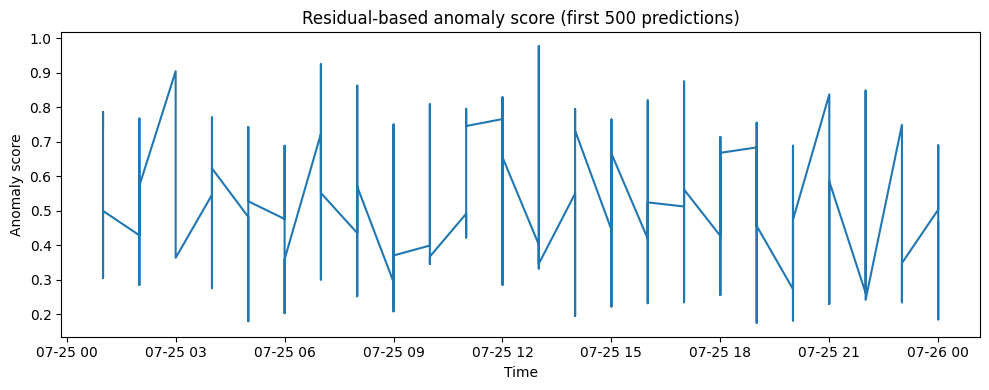

In [35]:
plt.figure(figsize=(10,4))
plt.plot(eval_df_small.index, eval_df_small['score'])
an_idx = eval_df_small[eval_df_small['is_anomaly']].index
plt.scatter(an_idx, eval_df_small.loc[an_idx,'score'], s=20)
plt.title('Residual-based anomaly score (first 500 predictions)')
plt.xlabel('Time')
plt.ylabel('Anomaly score')
plt.tight_layout()
plot_path = '/mnt/data/artifacts/anomaly_score_plot.png'
plt.savefig(plot_path)
plt.show()
plt.close()


In [26]:
np.save('/mnt/data/artifacts/X.npy', X)
np.save('/mnt/data/artifacts/Y.npy', Y)
pd.DataFrame(labels, index=pred_timestamps, columns=['Anomaly_Type']).to_csv('/mnt/data/artifacts/pred_labels.csv')


In [27]:
print("Artifacts saved to /mnt/data/artifacts:")
for p in sorted(os.listdir('/mnt/data/artifacts')):
    print(" -", p)


Artifacts saved to /mnt/data/artifacts:
 - X.npy
 - Y.npy
 - anomaly_score_plot.png
 - dqn_agent.pth
 - evaluation_table_head.csv
 - pred_labels.csv
 - robust_scaler.pkl
 - transformer_forecast.pth


In [28]:
print("\nDownloadable files (paths):")
print(" - Transformer model: /mnt/data/artifacts/transformer_forecast.pth")
print(" - DQN agent: /mnt/data/artifacts/dqn_agent.pth")
print(" - Scaler: /mnt/data/artifacts/robust_scaler.pkl")
print(" - Evaluation table (head): /mnt/data/artifacts/evaluation_table_head.csv")
print(" - Plot: /mnt/data/artifacts/anomaly_score_plot.png")



Downloadable files (paths):
 - Transformer model: /mnt/data/artifacts/transformer_forecast.pth
 - DQN agent: /mnt/data/artifacts/dqn_agent.pth
 - Scaler: /mnt/data/artifacts/robust_scaler.pkl
 - Evaluation table (head): /mnt/data/artifacts/evaluation_table_head.csv
 - Plot: /mnt/data/artifacts/anomaly_score_plot.png
